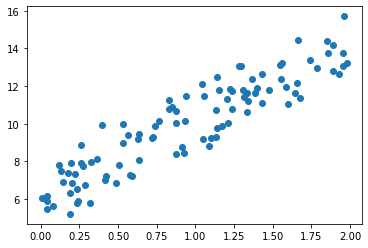

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
# y = 4X + 6을 근사(w1=4, w0=6), 임의의 값은 노이즈를 위해 만듦
x = 2 * np.random.rand(100,1)
y = 6 + 4 * x + np.random.randn(100,1)

# x, y 데이터 세트 산점도로 시각화
plt.scatter(x, y)

In [6]:
def get_cost(y, y_pred):
    n = len(y)
    cost = np.sum(np.square(y - y_pred))/n
    return cost

In [3]:
# w1과 w0를 업데이트할 w1_update, w0_update를 반환
def get_weight_updates(w1, w0, x, y, learning_rate=0.01):
    n = len(y)
    # 먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    # 예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(x, w1.T) + w0
    diff = y - y_pred
    
    # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    w0_factors = np.ones((n,1))
    
    # w1과 w0을 업데이트할 w1_update와 w0_update 계산
    w1_update = -(2/n)*learning_rate*(np.dot(x.T, diff))
    w0_update = -(2/n)*learning_rate*(np.dot(w0_factors.T, diff))
    
    return w1_update, w0_update

In [4]:
# 입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용함
def gradient_descent_steps(x, y, iters=10000):
    # w0와 w1을 모두 0으로 초기화
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    
    # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1, w0 업데이트 수행
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, x, y, learning_rate=0.01)
        w1 = w1- w1_update
        w0 = w0 - w0_update
    
    return w1, w0

In [7]:
w1, w0 = gradient_descent_steps(x, y, iters=1000)
print('w1:{0:.3f} w0:{1:.3f}'.format(w1[0,0], w0[0,0]))
y_pred = w1[0,0] * x + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


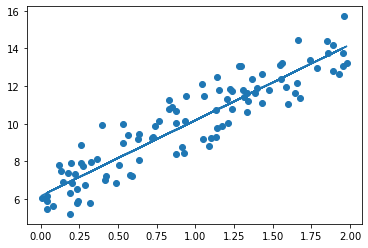

In [8]:
plt.scatter(x,y)
plt.plot(x, y_pred)

In [9]:
def stochastic_gradient_descent_steps(x, y, batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost = 100000
    iter_index = 0
    
    for ind in range(iters):
        np.random.seed(ind)
        # 전체 x, y 데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 sample_x, sample_y로 저장
        stochastic_random_index = np.random.permutation(x.shape[0])
        sample_x = x[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        # 랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_x, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
        
    return w1, w0

In [10]:
w1, w0 = stochastic_gradient_descent_steps(x, y, iters=1000)
print('w1:', round(w1[0,0],3), 'w0:', round(w0[0,0],3))
y_pred = w1[0,0] * x + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
%matplotlib inline

# boston 데이터 세트 로드
boston = load_boston()

# boston 데이터 세트 DataFrame 변환
bostonDF = pd.DataFrame(boston.data, columns = boston.feature_names)

# boston 데이터 세트의 target 배열은 주택 가격임, 이를 PRICE 칼럼으로 DataFrame에 추가함
bostonDF['PRICE'] = boston.target
print('Boston 데이터 세트 크기:', bostonDF.shape)
bostonDF.head()

Boston 데이터 세트 크기: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


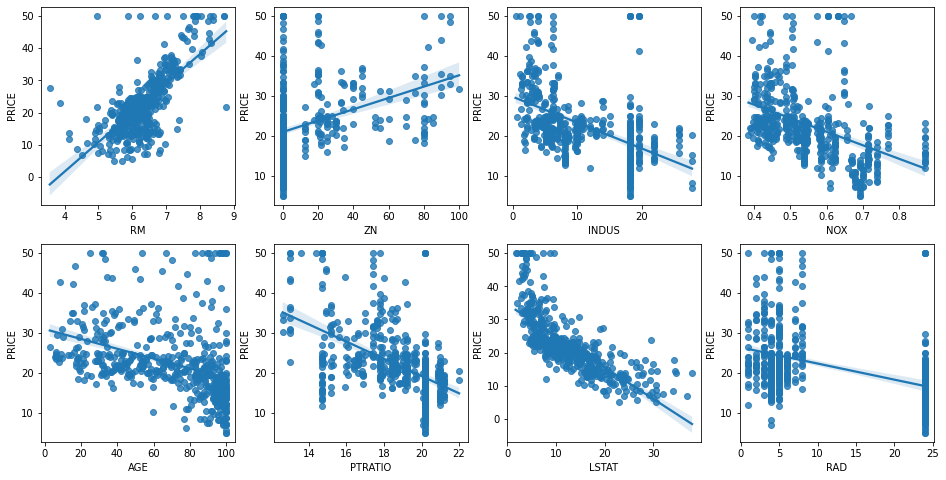

In [5]:
# 2개의 행과 4개의 열을 가진 subplots를 이용, axs는 4X2개의 ax를 가짐
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features = ['RM','ZN','INDUS','NOX','AGE','PTRATIO','LSTAT','RAD']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['PRICE']
x_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

x_train, x_test, y_train, y_test = train_test_split(x_data, y_target, test_size=0.3, random_state=156)

# 선형 회귀 OLS로 학습/예측/평가 수행
lr = LinearRegression()
lr.fit(x_train, y_train)
y_preds = lr.predict(x_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE : {1:.3f}'.format(mse, rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 17.297, RMSE : 4.159
Variance score : 0.757


In [7]:
print('절편 값:', lr.intercept_)
print('회귀 계수 값:', np.round(lr.coef_, 1))

절편 값: 40.99559517216444
회귀 계수 값: [ -0.1   0.1   0.    3.  -19.8   3.4   0.   -1.7   0.4  -0.   -0.9   0.
  -0.6]


In [8]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성, 인덱스 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=x_data.columns)
coeff.sort_values(ascending=False)

RM          3.4
CHAS        3.0
RAD         0.4
ZN          0.1
INDUS       0.0
AGE         0.0
TAX        -0.0
B           0.0
CRIM       -0.1
LSTAT      -0.6
PTRATIO    -0.9
DIS        -1.7
NOX       -19.8
dtype: float64

In [9]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
x_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

# cross_val_score()로 5 폴드 세트로 MSE를 구한 뒤 이를 기반으로 다시 RMSE 구함
neg_mse_scores = cross_val_score(lr, x_data, y_target, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring='neg_mean_squared_error')로 반환된 값은 모두 음수
print('5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print('5 folds 의 개별 RMSE scores: ', np.round(rmse_scores, 2))
print('5 folds 의 평균 RMSE: {0:.3f}'.format(avg_rmse))

5 folds 의 개별 Negative MSE scores:  [-12.46 -26.05 -33.07 -80.76 -33.31]
5 folds 의 개별 RMSE scores:  [3.53 5.1  5.75 8.99 5.77]
5 folds 의 평균 RMSE: 5.829


In [1]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1], [2,3]]의 2X2 행렬 생성
x = np.arange(4).reshape(2,2)
print('일차 단항식 계수 피처:\n', x)

# degree = 2인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용해 변환
poly = PolynomialFeatures(degree=2)
poly.fit(x)
poly_ftr = poly.transform(x)
print('변환된 2차 다항식 계수 피처:\n', poly_ftr)

일차 단항식 계수 피처:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 피처:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [2]:
def polynomial_func(x):
    y = 1 + 2*x[:,0] + 3*x[:,0]**2 + 4*x[:,1]**3
    return y

x = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature: \n', x)
y = polynomial_func(x)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
삼차 다항식 결정값: 
 [  5 125]


In [4]:
from sklearn.linear_model import LinearRegression

# 3차 다항식 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(x)
print('3차 다항식 계수 feature: \n', poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr, y)
print('Polynomial 회귀 계수\n', np.round(model.coef_, 2))
print('Polynomial 회귀 shape :', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 shape : (10,)


In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(x):
    y = 1 + 2*x[:,0] + 3*x[:,0]**2 + 4*x[:,1]**3
    return y

# Pipeline 객체로 Streamline하게 Polynomial Feature 변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
x = np.arange(4).reshape(2,2)
y = polynomial_func(x)

model = model.fit(x, y)

print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import cross_val_score 
%matplotlib inline 

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환 
def true_fun(x): 
    return np.cos(1.5 * np.pi * x) 

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다 
np.random.seed(0) 
n_samples = 30 
x = np.sort(np.random.rand(n_samples)) 

# Y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다 
y = true_fun(x) + np.random.randn(n_samples) * 0.1 


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE는 0.40772896250986845 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE는 0.043208749872317626 입니다.

Degree 15 회귀 계수는 [-2.98292000e+03  1.03899180e+05 -1.87415809e+06  2.03715961e+07
 -1.44873157e+08  7.09315008e+08 -2.47065753e+09  6.24561150e+09
 -1.15676562e+10  1.56895047e+10 -1.54006170e+10  1.06457389e+10
 -4.91378211e+09  1.35919860e+09 -1.70381087e+08] 입니다.
Degree 15 MSE는 182493841.77304456 입니다.


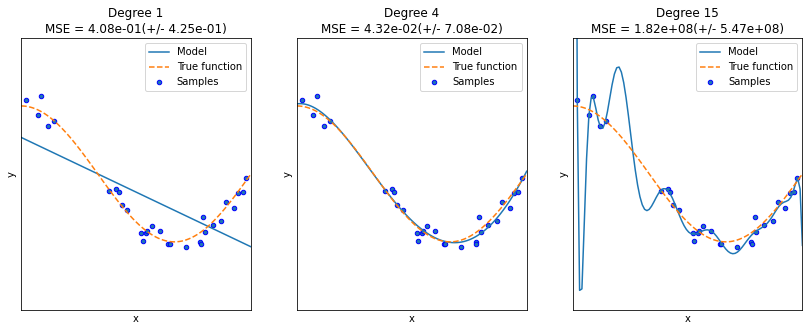

In [2]:
plt.figure(figsize=(14,5)) 
degrees = [1,4,15] 

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다 
for i in range(len(degrees)): 
    ax = plt.subplot(1, len(degrees), i + 1) 
    plt.setp(ax, xticks=(), yticks=()) 

    # 개별 degree별로 Polynomial 변환합니다 
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False) 
    linear_regression = LinearRegression() 
    pipeline = Pipeline([('polynomial_features', polynomial_features), 
                         ('linear_regression', linear_regression)]) 
    pipeline.fit(x.reshape(-1,1), y) 

    # 교차 검증으로 다항 회귀를 평가합니다 
    scores = cross_val_score(pipeline, x.reshape(-1,1), y, scoring='neg_mean_squared_error', cv=10) 
    #Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출 
    coefficients = pipeline.named_steps['linear_regression'].coef_ 
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2))) 
    print('Degree {0} MSE는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores))) 

    # 0부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다 
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다 
    x_test = np.linspace(0, 1, 100) 
    # 예측값 곡선 
    plt.plot(x_test, pipeline.predict(x_test[:, np.newaxis]), label='Model') 
    # 실제 값 곡선 
    plt.plot(x_test, true_fun(x_test), '--', label='True function') 
    plt.scatter(x, y, edgecolors='b', s=20, label='Samples') 
    plt.xlabel('x'); plt.ylabel('y'); plt.xlim((0,1)); plt.ylim((-2,2)); plt.legend(loc='best') 
    plt.title('Degree {}\nMSE = {:.2e}(+/- {:.2e})'.format(degrees[i], -scores.mean(), scores.std())) 

plt.show()

In [10]:
from sklearn.linear_model import Ridge 
from sklearn.model_selection import cross_val_score 

# alpha=10으로 설정해 릿지 회귀 수행 
ridge = Ridge(alpha=10) 
neg_mse_scores = cross_val_score(ridge, x_data, y_target, scoring='neg_mean_squared_error', cv=5) 
rmse_scores = np.sqrt(-1 * neg_mse_scores) 
avg_rmse = np.mean(rmse_scores) 

print('5 folds 의 개별 Negative MSE scores:', np.round(neg_mse_scores, 3)) 
print('5 folds 의 개별 RMSE scores:', np.round(rmse_scores, 3)) 
print('5 folds 의 평균 RMSE: {0:.3f}'.format(avg_rmse)) 

5 folds 의 개별 Negative MSE scores: [-11.422 -24.294 -28.144 -74.599 -28.517]
5 folds 의 개별 RMSE scores: [3.38  4.929 5.305 8.637 5.34 ]
5 folds 의 평균 RMSE: 5.518


In [11]:
# 릿지에 사용될 alpha 파라미터의 값을 정의 
alphas = [0, 0.1, 1, 10, 100] 

# alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함 
for alpha in alphas: 
    ridge = Ridge(alpha = alpha) 
    
    # cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산 
    neg_mse_scores = cross_val_score(ridge, x_data, y_target, scoring='neg_mean_squared_error', cv=5) 
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores)) 
    print('alpha {0} 일 때 5 folds 의 평균 RMSE : {1:.3f}'.format(alpha, avg_rmse)) 

alpha 0 일 때 5 folds 의 평균 RMSE : 5.829
alpha 0.1 일 때 5 folds 의 평균 RMSE : 5.788
alpha 1 일 때 5 folds 의 평균 RMSE : 5.653
alpha 10 일 때 5 folds 의 평균 RMSE : 5.518
alpha 100 일 때 5 folds 의 평균 RMSE : 5.330


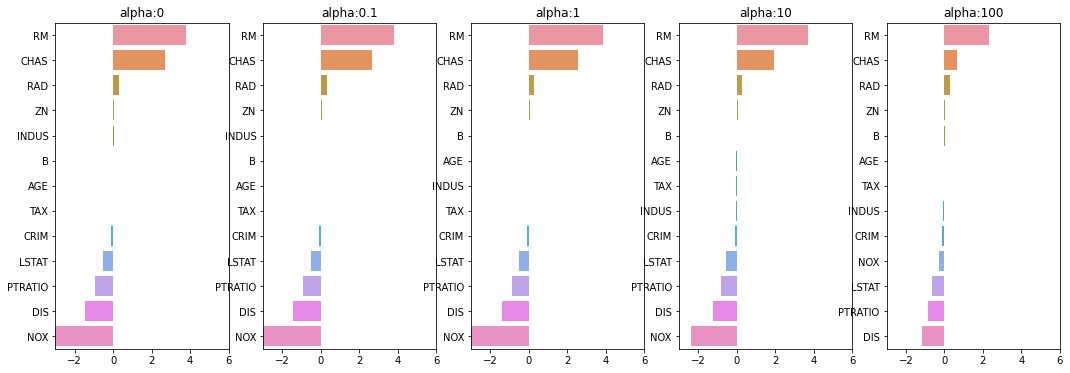

In [12]:
import seaborn as sns 

# 각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성 
fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=5) 
# 각 alpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 DataFrame 생성 
coeff_df = pd.DataFrame() 

# alphas 리스트 값을 차례로 입력해 회귀 계수 값 시각화 및 데이터 저장, pos는 axis의 위치 지정 
for pos, alpha in enumerate(alphas): 
    ridge = Ridge(alpha=alpha) 
    ridge.fit(x_data, y_target) 
    # alpha에 따른 피처별로 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가 
    coeff = pd.Series(data=ridge.coef_, index=x_data.columns) 
    colname = 'alpha:'+str(alpha) 
    coeff_df[colname] = coeff 
    # 막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화, 회귀 계수값이 높은 순으로 표현 
    coeff = coeff.sort_values(ascending=False) 
    axs[pos].set_title(colname) 
    axs[pos].set_xlim(-3,6) 
    sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos]) 

# for 문 바깥에서 맷플롯립의 show 호출 및 alpha에 따른 피처별 회귀 계수를 DataFrame으로 표시 
plt.show() 

In [13]:
ridge_alphas = [0, 0.1, 1, 10, 100] 
sort_column = 'alpha:'+str(ridge_alphas[0]) 
coeff_df.sort_values(by=sort_column, ascending=False) 

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,3.809865,3.818233,3.854000,3.702272,2.334536
CHAS,2.686734,2.670019,2.552393,1.952021,0.638335
RAD,0.306049,0.303515,0.290142,0.279596,0.315358
ZN,0.046420,0.046572,0.047443,0.049579,0.054496
INDUS,0.020559,0.015999,-0.008805,-0.042962,-0.052826
B,0.009312,0.009368,0.009673,0.010037,0.009393
AGE,0.000692,-0.000269,-0.005415,-0.010707,0.001212
TAX,-0.012335,-0.012421,-0.012912,-0.013993,-0.015856
CRIM,-0.108011,-0.107474,-0.104595,-0.101435,-0.102202
LSTAT,-0.524758,-0.525966,-0.533343,-0.559366,-0.660764


In [14]:
from sklearn.linear_model import Lasso, ElasticNet 

# alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환 
def get_linear_reg_eval(model_name, params=None, x_data_n=None, y_target_n=None, verbose=True, return_coeff=True): 
    coeff_df = pd.DataFrame() 
    if verbose : print('#######', model_name, '#######') 
    for param in params: 
        if model_name == 'Ridge': model = Ridge(alpha=param) 
        elif model_name == 'Lasso': model = Lasso(alpha=param) 
        elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7) 
        neg_mse_scores = cross_val_score(model, x_data_n, y_target_n, scoring='neg_mean_squared_error', cv=5) 
        avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores)) 
        print('alpha {0} 일 때 5 폴드 세트의 평균 RMSE: {1:.3f}'.format(param, avg_rmse)) 
        # cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출 

        model.fit(x_data_n, y_target_n) 
        if return_coeff: 
            # alpha에 따른 피처별 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가 
            coeff = pd.Series(data=model.coef_, index=x_data_n.columns) 
            colname = 'alpha:'+str(param) 
            coeff_df[colname] = coeff 

    return coeff_df 

# end of get_linear_regre_eval 

In [15]:
# 라쏘에 사용될 alpha 파라미터의 값을 정의하고 get_linear_reg_eval() 함수 호출 
lasso_alphas = [0.07, 0.1, 0.5, 1, 3] 
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, x_data_n=x_data, y_target_n=y_target) 

####### Lasso #######
alpha 0.07 일 때 5 폴드 세트의 평균 RMSE: 5.612
alpha 0.1 일 때 5 폴드 세트의 평균 RMSE: 5.615
alpha 0.5 일 때 5 폴드 세트의 평균 RMSE: 5.669
alpha 1 일 때 5 폴드 세트의 평균 RMSE: 5.776
alpha 3 일 때 5 폴드 세트의 평균 RMSE: 6.189


In [16]:
# 반환된 coeff_lasso_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력 
sort_column = 'alpha:'+str(lasso_alphas[0]) 
coeff_lasso_df.sort_values(by=sort_column, ascending=False) 

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.789725,3.703202,2.498212,0.949811,0.000000
CHAS,1.434343,0.955190,0.000000,0.000000,0.000000
RAD,0.270936,0.274707,0.277451,0.264206,0.061864
ZN,0.049059,0.049211,0.049544,0.049165,0.037231
B,0.010248,0.010249,0.009469,0.008247,0.006510
NOX,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
AGE,-0.011706,-0.010037,0.003604,0.020910,0.042495
TAX,-0.014290,-0.014570,-0.015442,-0.015212,-0.008602
INDUS,-0.042120,-0.036619,-0.005253,-0.000000,-0.000000
CRIM,-0.098193,-0.097894,-0.083289,-0.063437,-0.000000


In [17]:
# 엘라스틱넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출 
# l1_ratio는 0.7로 고정 
elastic_alphas = [0.07, 0.1, 0.5, 1, 3] 
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas, x_data_n=x_data, y_target_n=y_target) 

####### ElasticNet #######
alpha 0.07 일 때 5 폴드 세트의 평균 RMSE: 5.542
alpha 0.1 일 때 5 폴드 세트의 평균 RMSE: 5.526
alpha 0.5 일 때 5 폴드 세트의 평균 RMSE: 5.467
alpha 1 일 때 5 폴드 세트의 평균 RMSE: 5.597
alpha 3 일 때 5 폴드 세트의 평균 RMSE: 6.068


In [18]:
# 반환된 coeff_elastic_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력 
sort_column = 'alpha:'+str(elastic_alphas[0]) 
coeff_elastic_df.sort_values(by=sort_column, ascending=False) 

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.574162,3.414154,1.918419,0.938789,0.000000
CHAS,1.330724,0.979706,0.000000,0.000000,0.000000
RAD,0.278880,0.283443,0.300761,0.289299,0.146846
ZN,0.050107,0.050617,0.052878,0.052136,0.038268
B,0.010122,0.010067,0.009114,0.008320,0.007020
AGE,-0.010116,-0.008276,0.007760,0.020348,0.043446
TAX,-0.014522,-0.014814,-0.016046,-0.016218,-0.011417
INDUS,-0.044855,-0.042719,-0.023252,-0.000000,-0.000000
CRIM,-0.099468,-0.099213,-0.089070,-0.073577,-0.019058
NOX,-0.175072,-0.000000,-0.000000,-0.000000,-0.000000


In [35]:
# method는 표준 정규 분포 변환(Standard), 최댓값/최솟값 정규화(MinMax), 로그변환(Log) 결정 
# p_degree는 다항식 특성을 추가할 때 적용, p_degree는 2이상 부여하지 않음 
def get_scaled_data(method='None', p_degree=None, input_data=None): 
    if method == 'Standard': 
        scaled_data = StandardScaler().fit_transform(input_data) 
    elif method == 'MinMax': 
        scaled_data = MinMaxScaler().fit_transform(input_data) 
    elif method == 'Log': 
        scaled_data = np.log1p(input_data) 
    else: 
        scaled_data = input_data 

    if p_degree != None: 
        scaled_data = PolynomialFeatures(degree=p_degree, include_bias=False).fit_transform(scaled_data) 

    return scaled_data 

In [24]:
# Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출 
alphas = [0.1, 1, 10, 100] 

# 5개 방식으로 변환, 먼저 원본 그대로, 표준정규 분포, 표준정규 분포+다항식 특성 
# 최대/최소 정규화, 최대/최소 정규화+다항식 특성, 로그변환 
scale_methods = [(None, None), ('Standard',None), ('Standard',2), ('MinMax',None), ('MinMax',2), ('Log',None)] 
for scale_method in scale_methods: 
    x_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1], input_data=x_data) 
    print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1])) 
    get_linear_reg_eval('Ridge', params=alphas, x_data_n=x_data_scaled, y_target_n=y_target, verbose=False, return_coeff=False) 


## 변환 유형:None, Polynomial Degree:None
alpha 0.1 일 때 5 폴드 세트의 평균 RMSE: 5.788
alpha 1 일 때 5 폴드 세트의 평균 RMSE: 5.653
alpha 10 일 때 5 폴드 세트의 평균 RMSE: 5.518
alpha 100 일 때 5 폴드 세트의 평균 RMSE: 5.330

## 변환 유형:Standard, Polynomial Degree:None
alpha 0.1 일 때 5 폴드 세트의 평균 RMSE: 5.826
alpha 1 일 때 5 폴드 세트의 평균 RMSE: 5.803
alpha 10 일 때 5 폴드 세트의 평균 RMSE: 5.637
alpha 100 일 때 5 폴드 세트의 평균 RMSE: 5.421

## 변환 유형:Standard, Polynomial Degree:2
alpha 0.1 일 때 5 폴드 세트의 평균 RMSE: 8.827
alpha 1 일 때 5 폴드 세트의 평균 RMSE: 6.871
alpha 10 일 때 5 폴드 세트의 평균 RMSE: 5.485
alpha 100 일 때 5 폴드 세트의 평균 RMSE: 4.634

## 변환 유형:MinMax, Polynomial Degree:None
alpha 0.1 일 때 5 폴드 세트의 평균 RMSE: 5.764
alpha 1 일 때 5 폴드 세트의 평균 RMSE: 5.465
alpha 10 일 때 5 폴드 세트의 평균 RMSE: 5.754
alpha 100 일 때 5 폴드 세트의 평균 RMSE: 7.635

## 변환 유형:MinMax, Polynomial Degree:2
alpha 0.1 일 때 5 폴드 세트의 평균 RMSE: 5.298
alpha 1 일 때 5 폴드 세트의 평균 RMSE: 4.323
alpha 10 일 때 5 폴드 세트의 평균 RMSE: 5.185
alpha 100 일 때 5 폴드 세트의 평균 RMSE: 6.538

## 변환 유형:Log, Polynomial Degree:None
alpha 0.1 일 때 5 

In [25]:
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline 

from sklearn.datasets import load_breast_cancer 
from sklearn.linear_model import LogisticRegression 

cancer = load_breast_cancer() 

In [26]:
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 

# StandardScaler()로 평균이 0, 분산 1로 데이터 분포도 변환 
scaler = StandardScaler() 
data_scaled = scaler.fit_transform(cancer.data) 

x_train, x_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0) 

In [27]:
from sklearn.metrics import accuracy_score, roc_auc_score 

# 로지스틱 회귀를 이용해 학습 및 예측 수행 
lr_clf = LogisticRegression() 
lr_clf.fit(x_train, y_train) 
lr_preds = lr_clf.predict(x_test) 

# 정확도와 roc_auc 측정 
print('accuracy: {0:.3f}'.format(accuracy_score(y_test, lr_preds))) 
print('roc_auc: {0:.3f}'.format(roc_auc_score(y_test, lr_preds))) 

accuracy: 0.977
roc_auc: 0.972


In [28]:
from sklearn.model_selection import GridSearchCV 

params = {'penalty':['l2','l1'], 
          'C':[0.01, 0.1, 1, 3, 5, 10]} 

grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3) 
grid_clf.fit(data_scaled, cancer.target) 
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_, grid_clf.best_score_)) 

최적 하이퍼 파라미터:{'C': 1, 'penalty': 'l2'}, 최적 평균 정확도:0.975


C:\Users\rltjq\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:615: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\rltjq\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 598, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\rltjq\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1306, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\rltjq\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 443, in _check_solver
    raise ValueError("Solver %s supports only 'l2' or 'none' penalties, "
ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\rltjq\Anaconda3\lib\site-packages\sklearn\model_selection\_v

In [29]:
from sklearn.datasets import load_boston 
from sklearn.model_selection import cross_val_score 
from sklearn.ensemble import RandomForestRegressor 
import pandas as pd 
import numpy as np 

# 보스턴 데이터 세트 로드 
boston = load_boston() 
bostonDF = pd.DataFrame(boston.data, columns = boston.feature_names) 

bostonDF["PRICE"] = boston.target 
y_target = bostonDF['PRICE'] 
x_data = bostonDF.drop(["PRICE"], axis=1, inplace=False) 

rf = RandomForestRegressor(random_state=0, n_estimators=1000) 
neg_mse_scores = cross_val_score(rf, x_data, y_target, scoring='neg_mean_squared_error', cv=5) 
rmse_scores = np.sqrt(-1*neg_mse_scores) 
avg_rmse = np.mean(rmse_scores) 

print("5 교차 검증의 개별 Negative MSE scores:", np.round(neg_mse_scores, 2)) 
print('5 교차 검증의 개별 RMSE scores:', np.round(rmse_scores, 2)) 
print('5 교차 검증의 평균 RMSE: {0:.3f}'.format(avg_rmse)) 

5 교차 검증의 개별 Negative MSE scores: [ -7.88 -13.14 -20.57 -46.23 -18.88]
5 교차 검증의 개별 RMSE scores: [2.81 3.63 4.54 6.8  4.34]
5 교차 검증의 평균 RMSE: 4.423


In [30]:
def get_model_cv_prediction(model, x_data, y_target): 
    neg_mse_scores = cross_val_score(model, x_data, y_target, scoring='neg_mean_squared_error', cv=5) 
    rmse_scores = np.sqrt(-1 * neg_mse_scores) 
    avg_rmse = np.mean(rmse_scores) 
    print('#####', model.__class__.__name__,'#####') 
    print('5 교차 검증의 평균 RMSE: {0:.3f}'.format(avg_rmse)) 

In [31]:
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import GradientBoostingRegressor 
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor 

dt_reg = DecisionTreeRegressor(random_state=0, max_depth=4) 
rf_reg = RandomForestRegressor(random_state=0, n_estimators=1000) 
gb_reg = GradientBoostingRegressor(random_state=0, n_estimators=1000) 
xgb_reg = XGBRegressor(n_estimators=1000) 
lgb_reg = LGBMRegressor(n_estimators=1000) 

# 트리 기반의 회귀 모델을 반복하면서 평가 수행 
models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg] 
for model in models: 
    get_model_cv_prediction(model, x_data, y_target) 

##### DecisionTreeRegressor #####
5 교차 검증의 평균 RMSE: 5.978
##### RandomForestRegressor #####
5 교차 검증의 평균 RMSE: 4.423
##### GradientBoostingRegressor #####
5 교차 검증의 평균 RMSE: 4.269
##### XGBRegressor #####
5 교차 검증의 평균 RMSE: 4.251
##### LGBMRegressor #####
5 교차 검증의 평균 RMSE: 4.646


<AxesSubplot:>

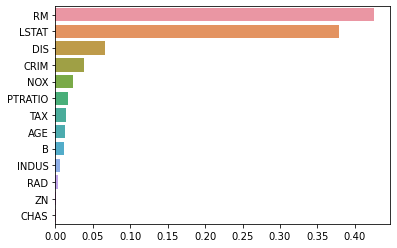

In [32]:
import seaborn as sns 
%matplotlib inline   

rf_reg = RandomForestRegressor(n_estimators=1000)   

# 앞 예제에서 만들어진 x_data, y_target 데이터 세트를 적용해 학습합니다 
rf_reg.fit(x_data, y_target) 

feature_series = pd.Series(data=rf_reg.feature_importances_, index=x_data.columns) 
feature_series = feature_series.sort_values(ascending=False) 
sns.barplot(x=feature_series, y=feature_series.index) 

        RM  PRICE
329  6.333   22.6
371  6.216   50.0
219  6.373   23.0
403  5.349    8.3
78   6.232   21.2
..     ...    ...
246  6.108   24.3
374  4.138   13.8
56   6.383   24.7
455  6.525   14.1
60   5.741   18.7

[100 rows x 2 columns]


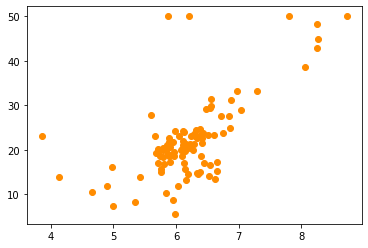

In [36]:
bostonDF_sample = bostonDF[['RM','PRICE']]
bostonDF_sample = bostonDF_sample.sample(n=100, random_state=0)
print(bostonDF_sample)
plt.figure()
plt.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c='darkorange')

In [39]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 선형 회귀와 결정 트리 기반의 Regressor 생성, DecisionTreeRegressor의 max_depth는 각각 2, 7
lr_reg = LinearRegression()
rf_reg2 = DecisionTreeRegressor(max_depth=2)
rf_reg7 = DecisionTreeRegressor(max_depth=7)

# 실제 예측을 적용할 테스트용 데이터 세트를 4.5~8.5까지의 100개 데이터 세트로 생성
x_test = np.arange(4.5,8.5,0.04).reshape(-1,1)

# 보스턴 주택 가격 데이터에서 시각화를 위해 피처는 RM만, 그리고 결정 데이터인 PRICE 추출
x_feature = bostonDF_sample['RM'].values.reshape(-1,1)
y_target = bostonDF_sample['PRICE'].values.reshape(-1,1)

# 학습과 예측 수행
lr_reg.fit(x_feature, y_target)
rf_reg2.fit(x_feature, y_target)
rf_reg7.fit(x_feature, y_target)

pred_lr = lr_reg.predict(x_test)
pred_rf2 = rf_reg2.predict(x_test)
pred_rf7 = rf_reg7.predict(x_test)

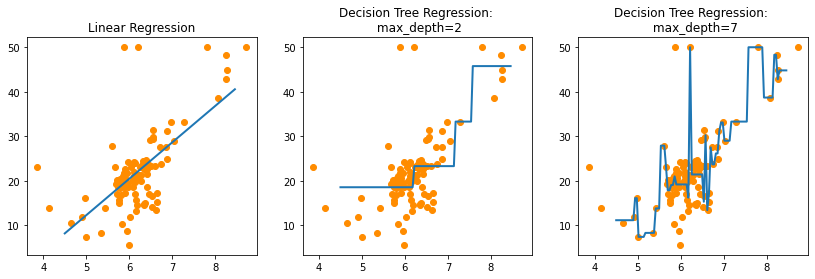

In [41]:
fig, (ax1,ax2,ax3) = plt.subplots(figsize=(14,4), ncols=3)

# X 축 값을 4.5~8.5로 변환하며 입력했을 때 선형 회귀와 결정 트리 회귀 예측선 시각화
# 선형 회귀로 학습된 모델 회귀 예측선
ax1.set_title('Linear Regression')
ax1.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c='darkorange')
ax1.plot(x_test, pred_lr, label='linear', linewidth=2)

# DecisionTreeRegression의 max_depth를 2로 했을 때 회귀 예측선
ax2.set_title('Decision Tree Regression: \n max_depth=2')
ax2.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c='darkorange')
ax2.plot(x_test, pred_rf2, label='max_depth:2', linewidth=2)

# DecisionTreeRegression의 max_depth를 7로 했을 때 회귀 예측선
ax3.set_title('Decision Tree Regression: \n max_depth=7')
ax3.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c='darkorange')
ax3.plot(x_test, pred_rf7, label='max_depth:7', linewidth=2)